In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1 Importando o arquivo

In [50]:
arquivo = r"https://raw.githubusercontent.com/vbomura/tc5/03b05a676fa48320170229c8be9c7a22fe5c0f7f/Codigos/base_anos_limpo.xlsx"

df = pd.read_excel(arquivo)

# 1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dosalunos (IAN) e como ele evolui ao longo do ano?

In [51]:
# df.sample(25)
df['fase'] = df['fase'].astype(str).replace({
    '0': 'ALFA',
    '1': 'FASE 1',
    '2': 'FASE 2',
    '3': 'FASE 3',
    '4': 'FASE 4',
    '5': 'FASE 5',
    '6': 'FASE 6',
    '7': 'FASE 7',
})
df['fase'].unique()

array(['FASE 7', 'FASE 6', 'FASE 5', 'FASE 4', 'FASE 3', 'FASE 2',
       'FASE 1', 'ALFA'], dtype=object)

## Analise por sexo

In [52]:
defasagens_escolhidas = [-3,-2,-1,0,1]
# defasagens_escolhidas = df['defasagem'].unique()

df_plot = df[df['defasagem'].isin(defasagens_escolhidas)].copy()

In [53]:
agrupado = (
    df_plot
    .groupby(['ano_aba', 'genero', 'defasagem'])
    .size()
    .reset_index(name='qtd')
)

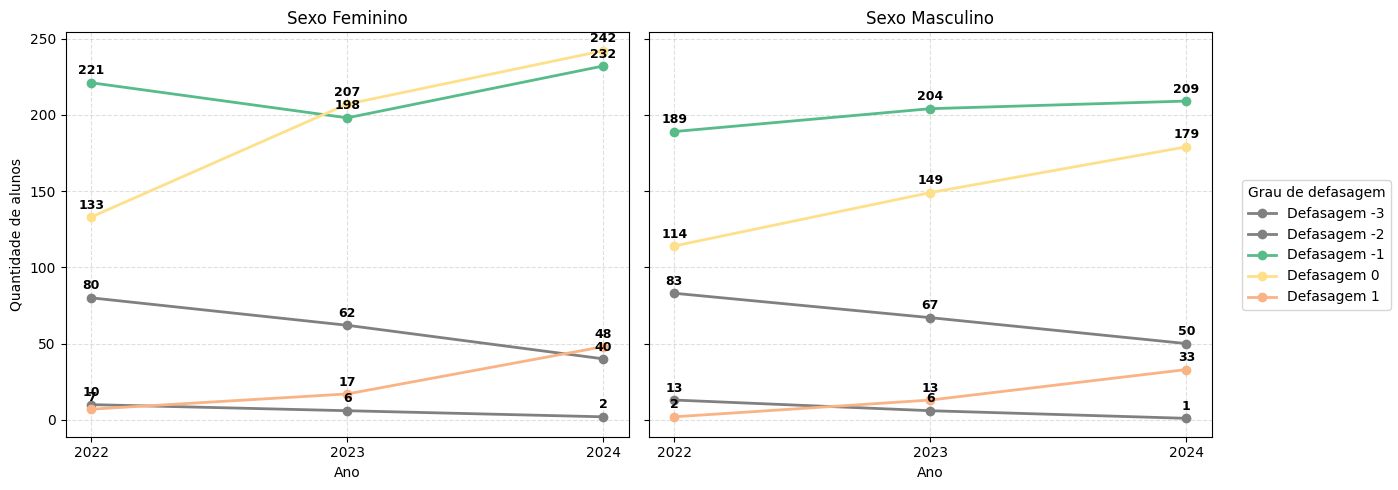

In [54]:
cores_defasagem = {
    -1: '#57BB8A', # Verde (Positivo)
     0: '#FEE08B', # Amarelo/Bege (Neutro)
     1: '#F9B384', # Laranja claro (Atenção)
     2: '#F98E52'  # Laranja escuro (Crítico)
}

sexos = ['Feminino', 'Masculino']
anos = sorted(df_plot['ano_aba'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sexo in zip(axes, sexos):
    dados_sexo = agrupado[agrupado['genero'] == sexo]

    for grau in defasagens_escolhidas:
        dados_grau = dados_sexo[dados_sexo['defasagem'] == grau]
        
        # Pega a cor do dicionário. Se o grau não estiver lá, usa cinza.
        cor = cores_defasagem.get(grau, '#808080')

        ax.plot(
            dados_grau['ano_aba'],
            dados_grau['qtd'],
            marker='o',
            color=cor,           # 🎨 AQUI entra a cor do seu Heatmap
            linewidth=2,         # Linha um pouco mais grossa para destacar a cor
            label=f'Defasagem {grau}'
        )

        # 🔢 Valor em cada ponto
        for x, y in zip(dados_grau['ano_aba'], dados_grau['qtd']):
            ax.annotate(
                str(y),
                (x, y),
                textcoords="offset points",
                xytext=(0, 6),
                ha='center',
                fontsize=9,
                weight='bold'    # Deixando o número em negrito como no Heatmap
            )
            
    ax.set_title(f'Sexo {sexo}')
    ax.set_xlabel('Ano')
    ax.grid(True, linestyle='--', alpha=0.4)

    # Força eixo X com anos inteiros
    ax.set_xticks(anos)
    ax.set_xticklabels([str(int(a)) for a in anos])

axes[0].set_ylabel('Quantidade de alunos')

# Legenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title='Grau de defasagem',
    loc='center right'
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

## Analise por fase

In [55]:
df['tipo_defasagem'] = df['defasagem'].apply(
    lambda x: 'Abaixo de zero' if x < 0 else 'Acima de zero'
)

In [56]:
agrupado = (
    df
    .groupby(['ano_aba', 'fase', 'tipo_defasagem'])
    .size()
    .reset_index(name='qtd')
)

In [57]:
tabela = (
    agrupado
    .pivot_table(
        index=['ano_aba', 'fase'],
        columns='tipo_defasagem',
        values='qtd',
        fill_value=0
    )
)


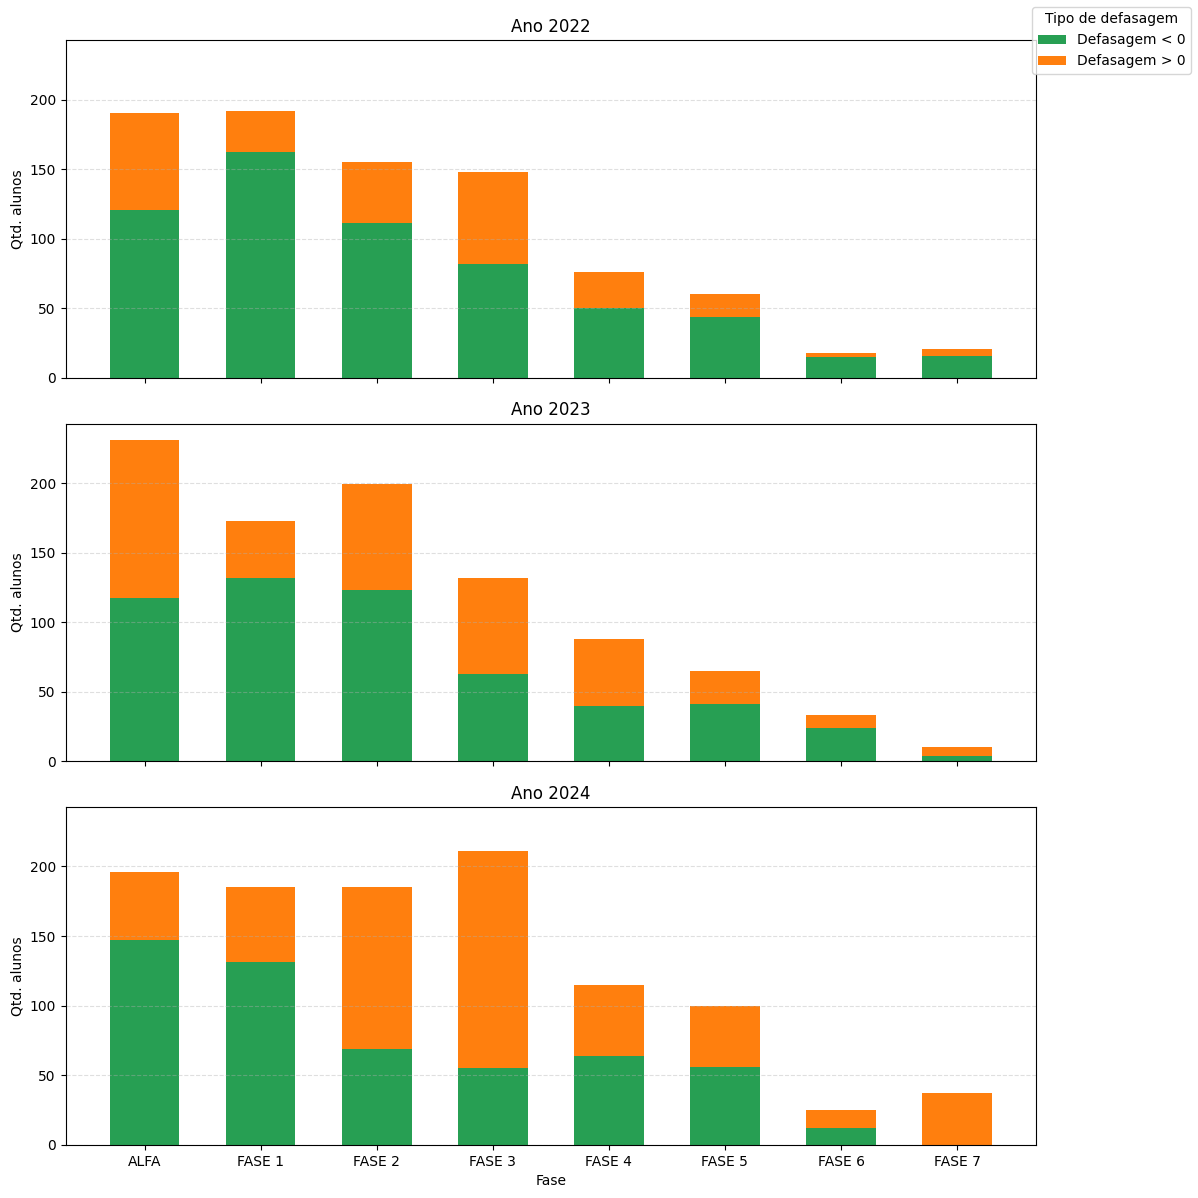

In [58]:
anos = sorted(tabela.index.get_level_values('ano_aba').unique())
fases = sorted(tabela.index.get_level_values('fase').unique())

x = np.arange(len(fases))
largura = 0.6  # barras mais largas (não há mais anos lado a lado)

# 🎨 cores fixas
cor_abaixo = '#279F53'  # azul
cor_acima = '#ff7f0e'   # laranja

fig, axes = plt.subplots(
    nrows=len(anos),
    ncols=1,
    figsize=(12, 4 * len(anos)),
    sharex=True,
    sharey=True
)

# Garante que axes seja iterável mesmo com 1 gráfico
if len(anos) == 1:
    axes = [axes]

for ax, ano in zip(axes, anos):
    dados_ano = tabela.loc[ano]

    abaixo = dados_ano['Abaixo de zero'].values
    acima = dados_ano['Acima de zero'].values

    # Barra empilhada
    ax.bar(
        x,
        abaixo,
        width=largura,
        color=cor_abaixo,
        label='Defasagem < 0'
    )

    ax.bar(
        x,
        acima,
        width=largura,
        bottom=abaixo,
        color=cor_acima,
        label='Defasagem > 0'
    )

    ax.set_title(f'Ano {ano}')
    ax.set_ylabel('Qtd. alunos')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Eixo X (apenas no último gráfico)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(fases, rotation=0)
axes[-1].set_xlabel('Fase')

# Legenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title='Tipo de defasagem',
    loc='upper right'
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


Quando analisamos em relação ao sexo podemos ver uma queda muito positiva em reção a defasagem -2 e -3, mostrando que menos casos de defasagem grande.
Podemos ver que para ambos os gêneros também tivemos uma boa "normalização", ou seja, inscritos que estão na fase adequada (Defasagem 0)
Alunos que estão com um nível de defasagem mostram que o grupo feminino conseguiu ter uma querda, mas em 2024 voltou a subir.
Vemos um aumento relativamente constante no úblico masculino

Temos uma tendência de alunos terem defasagem nas primeira (alfa 1, alfa 2 e alfa 3), movimento que ficou claro em 2024

# 2. Desempenho acadêmico (IDA)

In [59]:
df.head()

,ra,fase,turma,nome_anonimizado,idade,genero,ano_ingresso,instituicao_de_ensino,pedra,inde,...,ing,ipv,ian,fase_ideal_original,defasagem,ano_aba,fase_ideal,ipp,fase_original,tipo_defasagem
0,RA-1,FASE 7,A,Aluno-1,19,Feminino,2016,Escola Pública,Quartzo,5.783,...,6.0,7.278,5.0,Fase 8 (Universitários),-1,2022,FASE 8,NaN,NaN,Abaixo de zero
1,RA-2,FASE 7,A,Aluno-2,17,Feminino,2017,Rede Decisão,Ametista,7.055,...,9.7,6.778,10.0,Fase 7 (3º EM),0,2022,FASE 7,NaN,NaN,Acima de zero
2,RA-3,FASE 7,A,Aluno-3,17,Feminino,2016,Rede Decisão,Ágata,6.591,...,6.9,7.556,10.0,Fase 7 (3º EM),0,2022,FASE 7,NaN,NaN,Acima de zero
3,RA-4,FASE 7,A,Aluno-4,17,Masculino,2017,Rede Decisão,Quartzo,5.951,...,8.7,5.278,10.0,Fase 7 (3º EM),0,2022,FASE 7,NaN,NaN,Acima de zero
4,RA-5,FASE 7,A,Aluno-5,17,Feminino,2016,Rede Decisão,Ametista,7.427,...,5.7,7.389,10.0,Fase 7 (3º EM),0,2022,FASE 7,NaN,NaN,Acima de zero


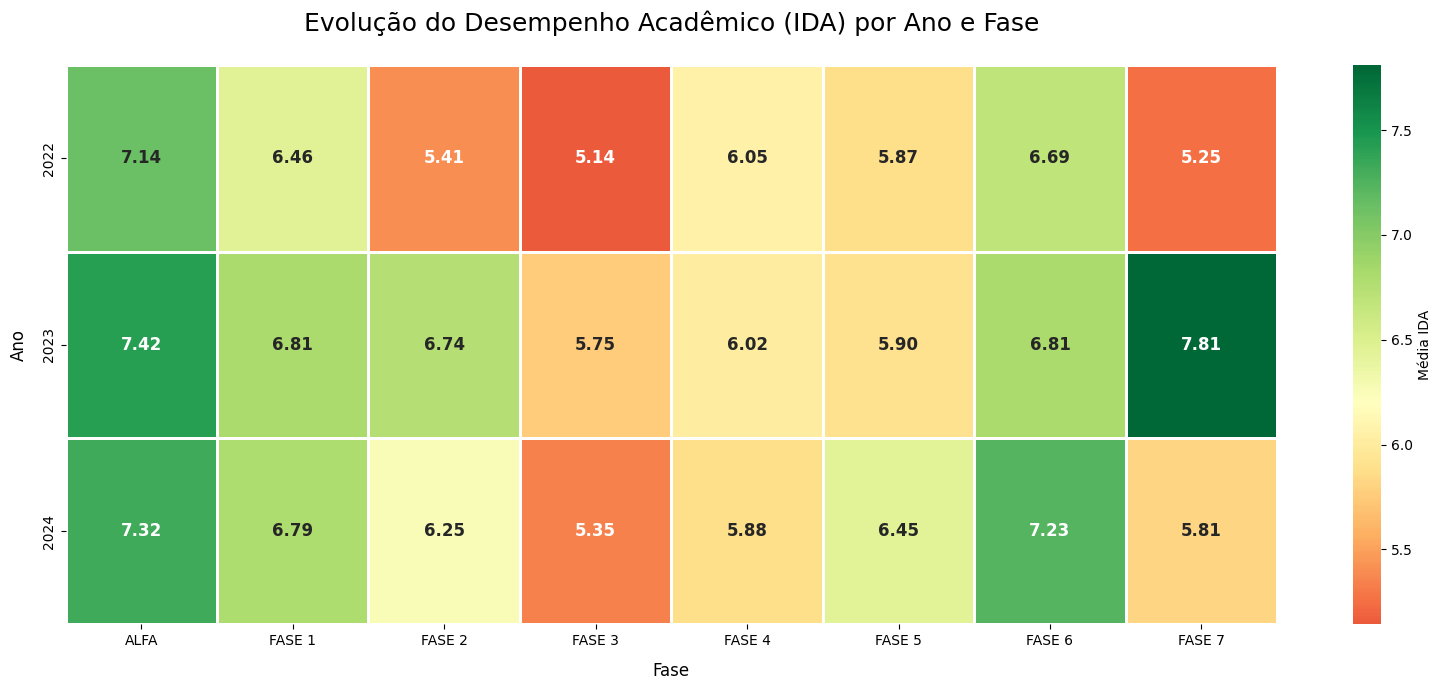

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Preparação dos Dados Dinâmica ---
# Criamos uma tabela dinâmica (matriz) onde:
# Index (linhas) = Ano
# Columns (colunas) = Fase
# Values (conteúdo) = Média do IDA
df_heatmap = df.pivot_table(
    index='ano_aba', 
    columns='fase', 
    values='ida', 
    aggfunc='mean'
)

# Opcional: Se as fases não estiverem na ordem correta (ALFA, FASE 1...), 
# você pode reordenar as colunas manualmente:
ordem_fases = ['ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4', 'FASE 5', 'FASE 6', 'FASE 7']
df_heatmap = df_heatmap.reindex(columns=ordem_fases)

# --- 2. Renderização do Gráfico (Idêntico à imagem) ---
plt.figure(figsize=(16, 7))

# Criando o Heatmap com Seaborn
ax = sns.heatmap(
    df_heatmap, 
    annot=True,           # Mostra os números
    fmt=".2f",            # 2 casas decimais
    cmap="RdYlGn",        # Paleta Red-Yellow-Green
    center=6.2,           # Ajusta o ponto médio para o bege (conforme a imagem)
    linewidths=1.0,       # Linhas brancas entre os blocos
    linecolor='white',    # Cor da linha divisória
    cbar_kws={'label': 'Média IDA'},
    annot_kws={"weight": "bold", "size": 12} # Texto em negrito
)

# --- 3. Ajustes de Estética ---
plt.title('Evolução do Desempenho Acadêmico (IDA) por Ano e Fase', fontsize=18, pad=25)
plt.xlabel('Fase', fontsize=12, labelpad=10)
plt.ylabel('Ano', fontsize=12, labelpad=10)

# Ajuste para garantir que o texto não fique cortado
plt.tight_layout()

plt.show()